# Importar librerías

In [14]:
# Librerías para cargar y manipular datos
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import ks_2samp

# Librerías para visualización
from matplotlib import pyplot as plt
import seaborn as sns

# Cargar recursos

Se cargan los resultados de la primera fase de experimentación de los modelos. Se cargan 2 tipos de resultados:

1. Los que tienen que ver con la validación para elegir el threshold adecuado para la detección de anomalías

2. Los que tienen que ver con el entrenamiento para monitorizar que este se ha ejecutado de forma correcta y corroborar el threshold elegido

In [15]:
# Directorio donde se encuentran los resultados de las ejecuciones de los experimentos
OUTPUT_FOLDER = Path("../../outputs/runs")

## Carga de los recursos de LOF por dispositivo

In [4]:
# Directorio donde se encuentran los resultados de la experimentación de los modelos LOF por dispositivo
LOF_OUTPUT_FOLDER = OUTPUT_FOLDER / "nbaiot_lof_per_device_stage_1" / "devices"

In [5]:
# Rutas de los archivos de scores de validación
LOF_DEVICE_1_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_1" / "val_scores.parquet"
LOF_DEVICE_2_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_2" / "val_scores.parquet"
LOF_DEVICE_3_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_3" / "val_scores.parquet"
LOF_DEVICE_4_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_4" / "val_scores.parquet"
LOF_DEVICE_5_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_5" / "val_scores.parquet"
LOF_DEVICE_6_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_6" / "val_scores.parquet"
LOF_DEVICE_7_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_7" / "val_scores.parquet"
LOF_DEVICE_8_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_8" / "val_scores.parquet"
LOF_DEVICE_9_VAL_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_9" / "val_scores.parquet"

# Rutas de los archivos de scores de entrenamiento
LOF_DEVICE_1_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_1" / "train_scores.parquet"
LOF_DEVICE_2_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_2" / "train_scores.parquet"
LOF_DEVICE_3_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_3" / "train_scores.parquet"
LOF_DEVICE_4_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_4" / "train_scores.parquet"
LOF_DEVICE_5_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_5" / "train_scores.parquet"
LOF_DEVICE_6_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_6" / "train_scores.parquet"
LOF_DEVICE_7_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_7" / "train_scores.parquet"
LOF_DEVICE_8_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_8" / "train_scores.parquet"
LOF_DEVICE_9_TRAIN_SCORES_PATH = LOF_OUTPUT_FOLDER / "device_9" / "train_scores.parquet"

In [6]:
# Dataframes para almacenar los scores de validación
lof_train_scores_df = pd.concat(
    [
        pd.read_parquet(LOF_DEVICE_1_TRAIN_SCORES_PATH).assign(device=1),
        pd.read_parquet(LOF_DEVICE_2_TRAIN_SCORES_PATH).assign(device=2),
        pd.read_parquet(LOF_DEVICE_3_TRAIN_SCORES_PATH).assign(device=3),
        pd.read_parquet(LOF_DEVICE_4_TRAIN_SCORES_PATH).assign(device=4),
        pd.read_parquet(LOF_DEVICE_5_TRAIN_SCORES_PATH).assign(device=5),
        pd.read_parquet(LOF_DEVICE_6_TRAIN_SCORES_PATH).assign(device=6),
        pd.read_parquet(LOF_DEVICE_7_TRAIN_SCORES_PATH).assign(device=7),
        pd.read_parquet(LOF_DEVICE_8_TRAIN_SCORES_PATH).assign(device=8),
        pd.read_parquet(LOF_DEVICE_9_TRAIN_SCORES_PATH).assign(device=9),
    ],
    ignore_index=True,
)

In [7]:
# Dataframes para almacenar los scores de entrenamiento
lof_val_scores_df = pd.concat(
    [
        pd.read_parquet(LOF_DEVICE_1_VAL_SCORES_PATH).assign(device=1),
        pd.read_parquet(LOF_DEVICE_2_VAL_SCORES_PATH).assign(device=2),
        pd.read_parquet(LOF_DEVICE_3_VAL_SCORES_PATH).assign(device=3),
        pd.read_parquet(LOF_DEVICE_4_VAL_SCORES_PATH).assign(device=4),
        pd.read_parquet(LOF_DEVICE_5_VAL_SCORES_PATH).assign(device=5),
        pd.read_parquet(LOF_DEVICE_6_VAL_SCORES_PATH).assign(device=6),
        pd.read_parquet(LOF_DEVICE_7_VAL_SCORES_PATH).assign(device=7),
        pd.read_parquet(LOF_DEVICE_8_VAL_SCORES_PATH).assign(device=8),
        pd.read_parquet(LOF_DEVICE_9_VAL_SCORES_PATH).assign(device=9),
    ],
    ignore_index=True,
)

## Carga de recursos de Autoencoder por dispositivo

In [3]:
# Directorio donde se encuentran los resultados de la experimentación de los modelos Autoencoder por dispositivo
AE_OUTPUT_FOLDER = OUTPUT_FOLDER / "nbaiot_autoencoder_per_device_stage_2" / "devices"

In [4]:
# Rutas de los archivos de los valores de la función de error en el dataset de validación
AE_DEVICE_1_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_1" / "val_reconstruction_errors.parquet"
AE_DEVICE_2_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_2" / "val_reconstruction_errors.parquet"
AE_DEVICE_3_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_3" / "val_reconstruction_errors.parquet"
AE_DEVICE_4_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_4" / "val_reconstruction_errors.parquet"
AE_DEVICE_5_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_5" / "val_reconstruction_errors.parquet"
AE_DEVICE_6_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_6" / "val_reconstruction_errors.parquet"
AE_DEVICE_7_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_7" / "val_reconstruction_errors.parquet"
AE_DEVICE_8_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_8" / "val_reconstruction_errors.parquet"
AE_DEVICE_9_VAL_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_9" / "val_reconstruction_errors.parquet"

# Rutas de los archivos de los valores de la función de error en el dataset de entrenamiento
AE_DEVICE_1_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_1" / "train_reconstruction_errors.parquet"
AE_DEVICE_2_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_2" / "train_reconstruction_errors.parquet"
AE_DEVICE_3_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_3" / "train_reconstruction_errors.parquet"
AE_DEVICE_4_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_4" / "train_reconstruction_errors.parquet"
AE_DEVICE_5_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_5" / "train_reconstruction_errors.parquet"
AE_DEVICE_6_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_6" / "train_reconstruction_errors.parquet"
AE_DEVICE_7_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_7" / "train_reconstruction_errors.parquet"
AE_DEVICE_8_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_8" / "train_reconstruction_errors.parquet"
AE_DEVICE_9_TRAIN_ERRORS_PATH = AE_OUTPUT_FOLDER / "device_9" / "train_reconstruction_errors.parquet"

In [5]:
# Dataframe para almacenar los valores de la función de error en el dataset de validación
ae_val_errors_df = pd.concat(
    [
        pd.read_parquet(AE_DEVICE_1_VAL_ERRORS_PATH).assign(device=1),
        pd.read_parquet(AE_DEVICE_2_VAL_ERRORS_PATH).assign(device=2),
        pd.read_parquet(AE_DEVICE_3_VAL_ERRORS_PATH).assign(device=3),
        pd.read_parquet(AE_DEVICE_4_VAL_ERRORS_PATH).assign(device=4),
        pd.read_parquet(AE_DEVICE_5_VAL_ERRORS_PATH).assign(device=5),
        pd.read_parquet(AE_DEVICE_6_VAL_ERRORS_PATH).assign(device=6),
        pd.read_parquet(AE_DEVICE_7_VAL_ERRORS_PATH).assign(device=7),
        pd.read_parquet(AE_DEVICE_8_VAL_ERRORS_PATH).assign(device=8),
        pd.read_parquet(AE_DEVICE_9_VAL_ERRORS_PATH).assign(device=9),
    ],
    ignore_index=True,
)

In [6]:
# Dataframe para almacenar los valores de la función de error en el dataset de entrenamiento
ae_train_errors_df = pd.concat(
    [
        pd.read_parquet(AE_DEVICE_1_TRAIN_ERRORS_PATH).assign(device=1),
        pd.read_parquet(AE_DEVICE_2_TRAIN_ERRORS_PATH).assign(device=2),
        pd.read_parquet(AE_DEVICE_3_TRAIN_ERRORS_PATH).assign(device=3),
        pd.read_parquet(AE_DEVICE_4_TRAIN_ERRORS_PATH).assign(device=4),
        pd.read_parquet(AE_DEVICE_5_TRAIN_ERRORS_PATH).assign(device=5),
        pd.read_parquet(AE_DEVICE_6_TRAIN_ERRORS_PATH).assign(device=6),
        pd.read_parquet(AE_DEVICE_7_TRAIN_ERRORS_PATH).assign(device=7),
        pd.read_parquet(AE_DEVICE_8_TRAIN_ERRORS_PATH).assign(device=8),
        pd.read_parquet(AE_DEVICE_9_TRAIN_ERRORS_PATH).assign(device=9),
    ],
    ignore_index=True,
)

## Carga de recursos de Autoencoder Global

In [16]:
# Ruta al archivo que contiene los valores de la función de error sobre el dataset de validación
AEG_VAL_ERRORS_PATH = OUTPUT_FOLDER / "nbaiot_autoencoder_global_stage_2" / "val_reconstruction_errors.parquet"

# Ruta al archivo que contiene los valores de la función de error sobre el dataset de entrenamiento
AEG_TRAIN_ERRORS_PATH = OUTPUT_FOLDER / "nbaiot_autoencoder_global_stage_2" / "train_reconstruction_errors.parquet"

In [17]:
# Dataframe para almacenar los valores de la función de error en el dataset de validación
aeg_val_errors_df = pd.read_parquet(AEG_VAL_ERRORS_PATH)

# Dataframe para almacenar los valores de la función de error en el dataset de entrenamiento
aeg_train_errors_df = pd.read_parquet(AEG_TRAIN_ERRORS_PATH)

# Estudio del *threshold* de LOF (*Local Outlier Factor*) por dispositivo

## 1. Caracterización de los *anomaly scores*

El primer paso del estudio consiste en analizar la distribución de los *anomaly scores* generados por los modelos LOF entrenados para cada dispositivo. Dado que cada modelo se ha entrenado únicamente con tráfico benigno, estos *scores* representan la respuesta del detector ante comportamiento considerado normal.

Este análisis tiene 2 objetivos principales:

1. Permite estudiar la forma de la distribución de *scores* benignos para cada dispositivo. 

2. Permite comparar el comportamiento observado en entrenamiento y validación. Esta comparación es importante porque el umbral de anomalía se seleccionará a partir del conjunto de validación, por lo que resulta necesario comprobar que la distribución de *scores* en validación es coherente con la observada durante el entrenamiento.

Para ello, se emplean gráficos combinados de tipo *violinplot* y *boxplot*. El *violinplot* permite visualizar la forma global de la distribución, mientras que el *boxplot* resume su tendencia central, dispersión intercuartílica y valores extremos. Además, se complementa el análisis visual con el test de Kolmogorov-Smirnov, que permite cuantificar si las distribuciones de entrenamiento y validación presentan diferencias estadísticamente significativas.

In [ ]:
# Juntar los dataframes de scores de entrenamiento y validación para poder graficarlos juntos
lof_train_plot_df = lof_train_scores_df.copy()
lof_train_plot_df["split"] = "Entrenamiento"

lof_val_plot_df = lof_val_scores_df.copy()
lof_val_plot_df["split"] = "Validación"

lof_scores_plot_df = pd.concat(
    [lof_train_plot_df, lof_val_plot_df],
    ignore_index=True,
)

lof_scores_plot_df["split"] = pd.Categorical(
    lof_scores_plot_df["split"],
    categories=["Entrenamiento", "Validación"],
    ordered=True,
)

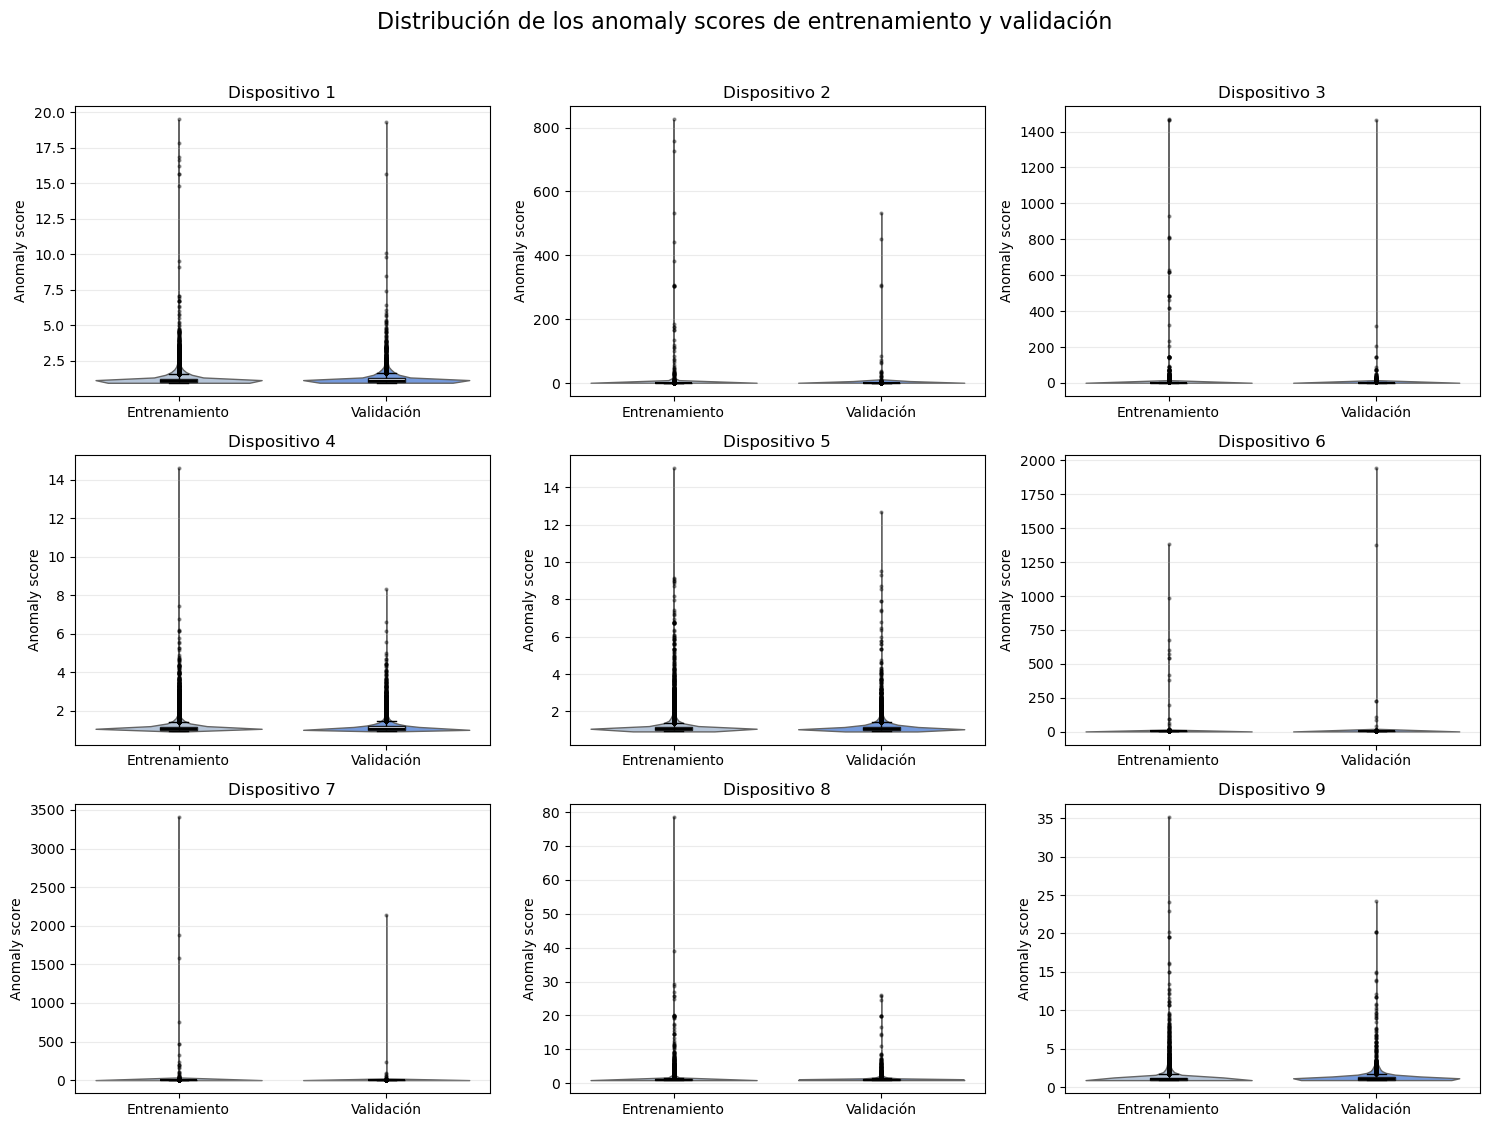

In [19]:
split_palette = {
    "Entrenamiento": "lightsteelblue",
    "Validación": "cornflowerblue",
}

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=False)
for ax, device_id in zip(axes.flatten(), range(1, 10)):
    device_scores_df = lof_scores_plot_df[
        lof_scores_plot_df["device"] == device_id
    ]

    sns.violinplot(
        data=device_scores_df,
        x="split",
        y="score",
        hue="split",
        palette=split_palette,
        inner=None,
        cut=0,
        linewidth=1,
        dodge=False,
        legend=False,
        ax=ax,
    )

    sns.boxplot(
        data=device_scores_df,
        x="split",
        y="score",
        width=0.18,
        showcaps=True,
        showfliers=True,
        boxprops={
            "facecolor": "white",
            "edgecolor": "black",
            "linewidth": 1,
            "alpha": 0.85,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1,
        },
        capprops={
            "color": "black",
            "linewidth": 1,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.5,
        },
        flierprops={
            "marker": "o",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 2,
            "alpha": 0.35,
        },
        ax=ax,
    )

    ax.set_title(f"Dispositivo {device_id}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Anomaly score")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Distribución de los anomaly scores de entrenamiento y validación",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()

In [11]:
ks_results = []
for device_id in sorted(lof_scores_plot_df["device"].unique()):
    train_scores = lof_train_scores_df.loc[
        lof_train_scores_df["device"] == device_id,
        "score",
    ].to_numpy()

    val_scores = lof_val_scores_df.loc[
        lof_val_scores_df["device"] == device_id,
        "score",
    ].to_numpy()

    ks_statistic, _ = ks_2samp(train_scores, val_scores)

    ks_results.append(
        {
            "device": device_id,
            "ks_statistic": ks_statistic,
            "train_mean": np.mean(train_scores),
            "val_mean": np.mean(val_scores),
            "train_median": np.median(train_scores),
            "val_median": np.median(val_scores),
            "train_std": np.std(train_scores),
            "val_std": np.std(val_scores),
            "train_max": np.max(train_scores),
            "val_max": np.max(val_scores),
        }
    )

ks_results_df = pd.DataFrame(ks_results)

ks_results_df

,device,ks_statistic,train_mean,val_mean,train_median,val_median,train_std,val_std,train_max,val_max
0,1,0.051116,1.188421,1.213018,1.054642,1.067816,0.444373,0.483593,19.500675,19.298923
1,2,0.017299,2.283123,2.109843,1.129069,1.123314,19.926058,16.313131,825.433167,532.555969
2,3,0.007801,2.690268,2.313819,1.117313,1.120541,23.513018,17.647846,1467.077515,1464.052368
3,4,0.039327,1.138021,1.151758,1.068821,1.079707,0.228690,0.244194,14.599893,8.308540
4,5,0.050451,1.143518,1.162001,1.049523,1.062431,0.351324,0.384403,15.016881,12.683290
5,6,0.047157,1.240753,1.346563,1.041710,1.051750,9.195938,17.145969,1382.818115,1943.231445
6,7,0.055129,1.536999,1.467731,1.038446,1.049043,24.697142,21.143850,3410.726562,2142.141357
7,8,0.049909,1.187845,1.207199,1.043669,1.055102,0.906120,0.792979,78.584511,25.925137
8,9,0.052292,1.318146,1.363022,1.069679,1.087157,0.974931,1.130840,35.170509,24.164722


Las distribuciones de *anomaly scores* obtenidas para los nueve modelos LOF presentan un comportamiento muy similar entre los conjuntos de entrenamiento y validación. Esta observación se confirma tanto visualmente mediante los diagramas de violín y cajas como cuantitativamente a través del estadístico de Kolmogorov-Smirnov. En todos los dispositivos, el valor del estadístico KS es inferior a 0.06, lo que indica que las diferencias entre ambas distribuciones son reducidas. Por tanto, puede considerarse que el conjunto de validación constituye una representación adecuada del comportamiento benigno aprendido durante el entrenamiento y, en consecuencia, resulta apropiado utilizarlo para la selección del *threshold* de detección de anomalías.

Otro aspecto destacable es que las distribuciones presentan una marcada asimetría positiva. La mayor parte de las muestras benignas se concentra en torno a valores de *anomaly score* próximos a la unidad, mientras que existe un reducido número de observaciones que alcanzan valores considerablemente superiores. Esta característica se refleja tanto en la diferencia entre la media y la mediana como en la elevada desviación típica observada en algunos dispositivos, especialmente en los dispositivos 2, 3, 6 y 7, donde aparecen valores máximos superiores a 500 e incluso superiores a 3000.

La presencia de estos valores extremos resulta especialmente relevante para el estudio del *threshold*, ya que evidencia que algunas observaciones benignas reciben *anomaly scores* considerablemente superirores al resto de muestras benignas. En consecuencia, la selección del umbral no puede basarse únicamente en medidas de tendencia central, sino que deberá considerar el comportamiento de la cola de la distribución y la frecuencia con la que aparecen estos eventos extremos. Esta observación servirá de base para analizar, en los siguientes apartados, distintos criterios de selección del *threshold* adecuados para distribuciones altamente asimétricas.

## 2. Selección del criterio de *threshold*

Una vez caracterizadas las distribuciones de *anomaly scores*, el siguiente paso consiste en estudiar qué criterio resulta más adecuado para fijar el *threshold* de cada modelo LOF. El umbral se selecciona utilizando únicamente el conjunto de validación, compuesto por tráfico benigno, manteniendo así la naturaleza no supervisada de la metodología experimental.

Los resultados del apartado anterior muestran que las distribuciones de *scores* presentan una fuerte asimetría positiva y colas derechas con valores extremos. Por este motivo, no se consideran adecuados criterios basados en supuestos de normalidad, como la media más varias desviaciones típicas, ya que la media y la desviación estándar pueden verse fuertemente afectadas por observaciones extremas.

En su lugar, se analizan criterios no paramétricos y robustos, basados únicamente en la distribución empírica de los *scores* benignos de validación. Concretamente, se estudian dos familias de criterios:

- **Criterios basados en percentiles altos**, que permiten controlar explícitamente la proporción máxima esperada de muestras benignas que quedarían por encima del *threshold*.
- **Criterios basados en el rango intercuartílico**, que utilizan una medida robusta de dispersión para identificar valores alejados del cuerpo principal de la distribución.

Para cada criterio se calcula, por dispositivo, el *threshold* resultante y la tasa de falsas alarmas estimada sobre validación:

$$
\mathrm{FPR}_{\mathrm{val}}(t)=
\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}(s_i>t)
$$

donde \(s_i\) representa el *anomaly score* de una muestra benigna de validación y \(N\) el número total de muestras de validación del dispositivo correspondiente.

In [37]:
# Definición de criterios para calcular los thresholds de anomalía a partir de los scores de validación
threshold_criteria = {
    "p99": lambda scores: np.percentile(scores, 99),
    "p99_5": lambda scores: np.percentile(scores, 99.5),
    "p99_9": lambda scores: np.percentile(scores, 99.9),
    "iqr_1_5": lambda scores: (
        np.percentile(scores, 75)
        + 1.5 * (np.percentile(scores, 75) - np.percentile(scores, 25))
    ),
    "iqr_3": lambda scores: (
        np.percentile(scores, 75)
        + 3.0 * (np.percentile(scores, 75) - np.percentile(scores, 25))
    ),
}

# Cálculo de thresholds y FPR para cada dispositivo y criterio de threshold
results = []
for device in sorted(lof_val_scores_df["device"].unique()):

    scores = lof_val_scores_df.loc[
        lof_val_scores_df["device"] == device,
        "score"
    ].to_numpy()

    for criterion, func in threshold_criteria.items():

        threshold = func(scores)

        results.append({
            "device": device,
            "criterion": criterion,
            "threshold": threshold,
            "fpr (%)": 100 * np.mean(scores > threshold),
        })

results_df = pd.DataFrame(results)

# Tabla de thresholds
print("Tabla de thresholds:")
display(results_df.pivot(
    index="device",
    columns="criterion",
    values="threshold",
).round(4))

# Tabla de FPR
print("Tabla de FPR:")
display(results_df.pivot(
    index="device",
    columns="criterion",
    values="fpr (%)",
).round(4))

Tabla de thresholds:


criterion,iqr_1_5,iqr_3,p99,p99_5,p99_9
device,,,,,
1,1.5862,1.9331,2.9840,3.537800,5.675600
2,1.7081,2.1208,6.2190,26.156401,305.468109
3,2.7376,3.7749,15.4133,24.458099,72.860901
4,1.4584,1.7217,2.0849,2.425200,3.566000
5,1.4403,1.6995,2.6026,3.213400,5.906700
6,1.3770,1.5994,2.4490,3.146400,7.622800
7,1.4465,1.7118,3.7893,5.642200,16.265600
8,1.4373,1.6969,3.2468,4.797400,13.249900
9,1.7636,2.2141,5.8626,9.106900,15.522900


Tabla de FPR:


criterion,iqr_1_5,iqr_3,p99,p99_5,p99_9
device,,,,,
1,10.1110,4.4097,1.0091,0.5045,0.1009
2,9.7598,5.9474,1.0294,0.5337,0.1144
3,13.1330,8.2481,1.0102,0.5115,0.1023
4,7.1302,2.6307,1.0015,0.5022,0.1027
5,8.4225,3.9981,1.0056,0.5068,0.1046
6,8.9022,4.5069,1.0049,0.5025,0.1015
7,10.3739,6.0115,1.0067,0.5081,0.1055
8,10.4433,6.1071,1.0089,0.5045,0.1073
9,10.5223,6.2980,1.0241,0.5120,0.1024


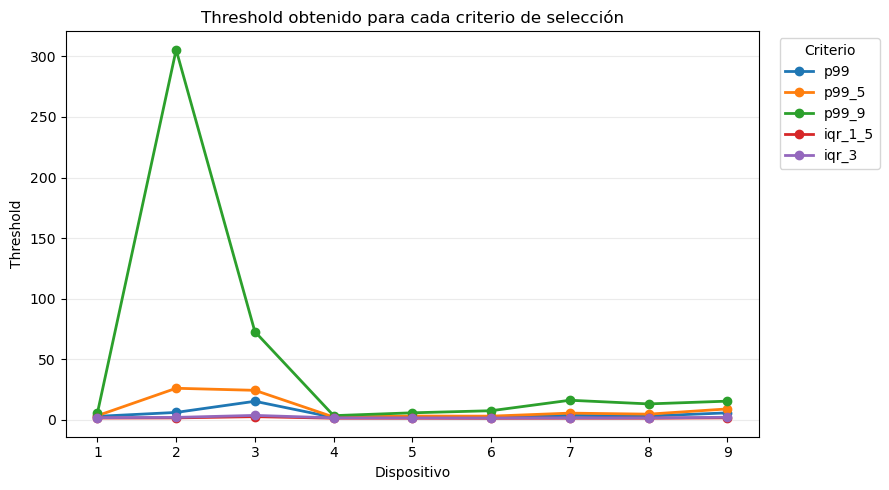

In [40]:
plt.figure(figsize=(9, 5))

for criterion in results_df["criterion"].unique():
    criterion_df = results_df[results_df["criterion"] == criterion]

    plt.plot(
        criterion_df["device"],
        criterion_df["threshold"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("Threshold obtenido para cada criterio de selección")
plt.xlabel("Dispositivo")
plt.ylabel("Threshold")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

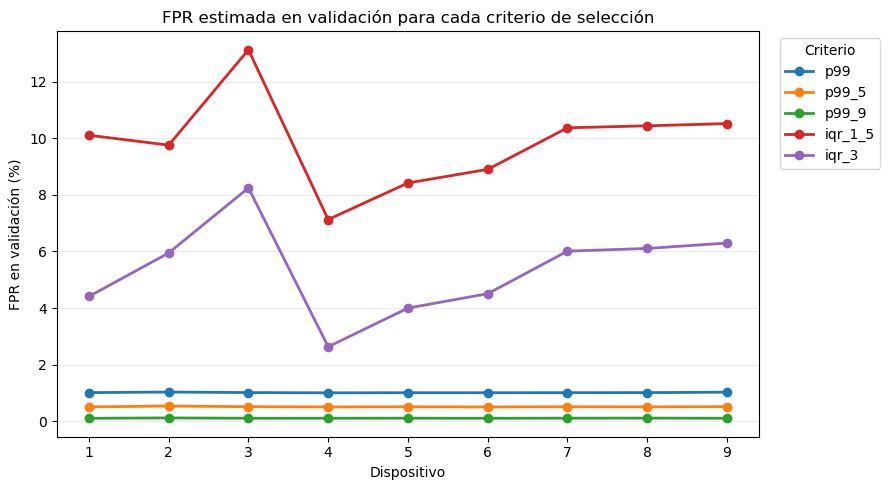

In [42]:
plt.figure(figsize=(9, 5))

for criterion in results_df["criterion"].unique():
    criterion_df = results_df[results_df["criterion"] == criterion]

    plt.plot(
        criterion_df["device"],
        criterion_df["fpr (%)"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("FPR estimada en validación para cada criterio de selección")
plt.xlabel("Dispositivo")
plt.ylabel("FPR en validación (%)")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Los resultados obtenidos muestran diferencias claras entre las 2 familias de criterios evaluadas. Los métodos basados en el rango intercuartílico generan thresholds relativamente próximos al cuerpo principal de la distribución, lo que se traduce en tasas de falsas alarmas considerablemente elevadas. En concreto, el criterio **IQR + 1.5** produce una FPR comprendida aproximadamente entre el 7 % y el 13 %, mientras que **IQR + 3** reduce dicha tasa hasta valores situados entre el 2.5 % y el 8 %. Aunque estos criterios son ampliamente utilizados para la detección de valores atípicos, las tasas de falsas alarmas obtenidas resultan excesivas para un sistema de detección de intrusiones, donde un elevado número de falsas alarmas dificulta su utilización práctica. Por este motivo, ambos criterios se descartan para el resto del estudio.

Por el contrario, los criterios basados en percentiles altos presentan un comportamiento significativamente más adecuado. Como era esperable, los percentiles **P99**, **P99.5** y **P99.9** permiten controlar de forma explícita la tasa máxima de falsas alarmas sobre el conjunto de validación, obteniéndose valores próximos al 1 %, 0.5 % y 0.1 %, respectivamente, en todos los dispositivos. Además, al tratarse de criterios no paramétricos, su cálculo depende únicamente de la distribución empírica de los *anomaly scores*, evitando realizar hipótesis sobre su forma, aspecto especialmente relevante dadas las distribuciones altamente asimétricas observadas en el apartado anterior.

No obstante, el análisis de los thresholds obtenidos pone de manifiesto una diferencia importante entre los tres percentiles evaluados. Mientras que los thresholds asociados a **P99** y **P99.5** evolucionan de forma relativamente gradual entre dispositivos, el criterio **P99.9** produce incrementos muy acusados en algunos de ellos, especialmente en aquellos que presentan colas de distribución más largas. Este comportamiento sugiere que dicho criterio podría depender en mayor medida de un número muy reducido de observaciones extremas presentes en la cola superior de la distribución.

A partir de estos resultados no es posible determinar todavía cuál de los tres percentiles constituye la mejor elección para definir el threshold. Sin embargo, el análisis realizado permite reducir el conjunto de candidatos a **P99**, **P99.5** y **P99.9**, descartando los criterios basados en el rango intercuartílico. En el siguiente apartado se estudiará la estabilidad de los thresholds obtenidos mediante cada uno de estos percentiles, con el objetivo de evaluar su sensibilidad frente a pequeñas variaciones en el conjunto de validación y seleccionar finalmente el criterio más robusto para todos los dispositivos.

## 3. Estabilidad de los *thresholds* seleccionados

En el apartado anterior se descartaron los criterios basados en el rango intercuartílico debido a la elevada tasa de falsas alarmas estimada sobre validación. Por tanto, en este apartado se estudia únicamente la estabilidad de los criterios basados en percentiles altos: **P99**, **P99.5** y **P99.9**.

El objetivo es analizar hasta qué punto el threshold obtenido por cada criterio depende de la muestra concreta de validación utilizada. Para ello se aplica un procedimiento de *bootstrap* sobre los *anomaly scores* de validación de cada dispositivo. En cada iteración se genera una nueva muestra con reemplazo a partir de los scores originales y se recalcula el threshold correspondiente.

Si un criterio produce thresholds muy similares entre remuestreos, puede considerarse más estable. Por el contrario, si pequeñas variaciones en la muestra de validación generan thresholds muy diferentes, el criterio será más sensible a la composición concreta de la cola de la distribución.

Dado que cada dispositivo presenta una escala distinta de *anomaly scores*, la estabilidad se compara mediante el coeficiente de variación:

$$
CV = \frac{\sigma_{\mathrm{bootstrap}}}{\mu_{\mathrm{bootstrap}}}
$$

donde $\mu_{\mathrm{bootstrap}}$ y $\sigma_{\mathrm{bootstrap}}$ representan, respectivamente, la media y la desviación típica de los thresholds obtenidos mediante bootstrap. Un menor valor de $CV$ indica una mayor estabilidad relativa del criterio.

In [51]:
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

bootstrap_criteria = {
    "P99": 99,
    "P99.5": 99.5,
    "P99.9": 99.9,
}

rng = np.random.default_rng(RANDOM_SEED)

bootstrap_results = []

for device in sorted(lof_val_scores_df["device"].unique()):
    scores = lof_val_scores_df.loc[
        lof_val_scores_df["device"] == device,
        "score"
    ].to_numpy()

    n_samples = len(scores)

    for criterion, percentile in bootstrap_criteria.items():
        thresholds = []

        for _ in range(N_BOOTSTRAP):
            bootstrap_sample = rng.choice(
                scores,
                size=n_samples,
                replace=True,
            )

            thresholds.append(
                np.percentile(bootstrap_sample, percentile)
            )

        thresholds = np.array(thresholds)

        bootstrap_results.append({
            "device": device,
            "criterion": criterion,
            "mean_threshold": thresholds.mean(),
            "std_threshold": thresholds.std(ddof=1),
            "cv_threshold": thresholds.std(ddof=1) / thresholds.mean(),
            "ci_2_5": np.percentile(thresholds, 2.5),
            "ci_97_5": np.percentile(thresholds, 97.5),
        })

bootstrap_results_df = pd.DataFrame(bootstrap_results)

In [52]:
bootstrap_cv_table = (
    bootstrap_results_df
    .pivot(
        index="device",
        columns="criterion",
        values="cv_threshold",
    )
    .round(6)
)

bootstrap_cv_table

criterion,P99,P99.5,P99.9
device,,,
1,0.045787,0.037201,0.104946
2,0.407370,0.405348,0.548342
3,0.090358,0.127829,0.339074
4,0.011293,0.019652,0.033245
5,0.030005,0.045271,0.114629
6,0.022844,0.039056,0.170005
7,0.047651,0.071544,0.510896
8,0.042004,0.073878,0.326760
9,0.093157,0.126706,0.181220


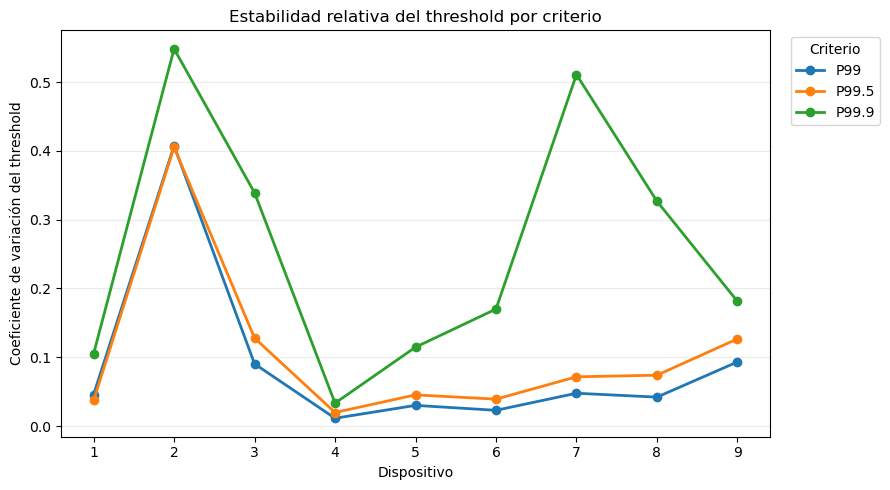

In [53]:
plt.figure(figsize=(9, 5))

for criterion in bootstrap_results_df["criterion"].unique():
    criterion_df = bootstrap_results_df[
        bootstrap_results_df["criterion"] == criterion
    ]

    plt.plot(
        criterion_df["device"],
        criterion_df["cv_threshold"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("Estabilidad relativa del threshold por criterio")
plt.xlabel("Dispositivo")
plt.ylabel("Coeficiente de variación del threshold")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Los resultados obtenidos mediante el procedimiento de *bootstrap* confirman la hipótesis planteada al finalizar el apartado anterior. Aunque los criterios **P99.5** y **P99.9** permiten reducir progresivamente la tasa de falsas alarmas estimada sobre el conjunto de validación, dicha reducción se consigue a costa de una menor estabilidad del threshold. En particular, el criterio **P99.9** presenta los mayores coeficientes de variación en la mayoría de los dispositivos, lo que indica una elevada sensibilidad frente a pequeñas variaciones en la composición de la muestra de validación. Este comportamiento resulta coherente con el análisis realizado en el apartado anterior, donde se observó que los thresholds asociados a este criterio dependían en gran medida de la cola extrema de la distribución de *anomaly scores*.

Por el contrario, el criterio **P99** proporciona de forma sistemática los menores coeficientes de variación en prácticamente todos los dispositivos analizados. Aunque la tasa de falsas alarmas estimada sobre validación es ligeramente superior a la obtenida mediante **P99.5** y **P99.9**, dicha diferencia es reducida (aproximadamente un 0.5 % y un 0.9 %, respectivamente), mientras que la mejora en estabilidad resulta considerable. Este comportamiento representa un mejor equilibrio entre robustez y capacidad de generalización, ya que el threshold obtenido depende en menor medida de observaciones extremas presentes en el conjunto de validación.

**Como resultado de este estudio, se selecciona el percentil P99 como criterio común para la determinación del threshold de detección de anomalías en todos los modelos LOF entrenados.** Esta decisión permite mantener una metodología homogénea para todos los dispositivos, adaptando únicamente el valor numérico del threshold a la distribución de *anomaly scores* de cada modelo.

Los thresholds finalmente seleccionados para cada dispositivo son los siguientes:

- **Dispositivo 1:** 2.9840
- **Dispositivo 2:** 6.2190
- **Dispositivo 3:** 15.4133
- **Dispositivo 4:** 2.0849
- **Dispositivo 5:** 2.6026
- **Dispositivo 6:** 2.4490
- **Dispositivo 7:** 3.7893
- **Dispositivo 8:** 3.2468
- **Dispositivo 9:** 5.8626

Con ello queda finalizada la primera fase del experimento correspondiente al entrenamiento y validación de modelos LOF específicos por dispositivo. Los thresholds obtenidos serán empleados, sin modificaciones adicionales, durante la fase de evaluación sobre el conjunto de test, donde se analizará la capacidad de detección de ataques y el comportamiento del sistema frente a datos no utilizados durante el entrenamiento ni la selección del threshold.

# Estudio del *threshold* de Autoencoder por dispositivo

## 1. Caracterización de los errores de reconstrucción

Al igual que en el estudio realizado para LOF, antes de seleccionar un criterio para el cálculo del threshold resulta necesario analizar el comportamiento de la distribución de los errores de reconstrucción obtenidos sobre el conjunto de validación.

En este caso, el error de reconstrucción se calcula mediante el error cuadrático medio (MSE) entre cada muestra de entrada y su reconstrucción generada por el autoencoder. Dado que el modelo ha sido entrenado exclusivamente con tráfico benigno, la distribución de estos errores caracteriza el comportamiento normal aprendido por el detector y constituye la base para la definición de un threshold de detección de anomalías.

In [13]:
# Juntar los dataframes de errores de reconstrucción de entrenamiento y validación para poder graficarlos juntos
ae_train_plot_df = ae_train_errors_df.copy()
ae_train_plot_df["split"] = "Entrenamiento"

ae_val_plot_df = ae_val_errors_df.copy()
ae_val_plot_df["split"] = "Validación"

ae_errors_plot_df = pd.concat(
    [ae_train_plot_df, ae_val_plot_df],
    ignore_index=True,
)

ae_errors_plot_df["split"] = pd.Categorical(
    ae_errors_plot_df["split"],
    categories=["Entrenamiento", "Validación"],
    ordered=True,
)

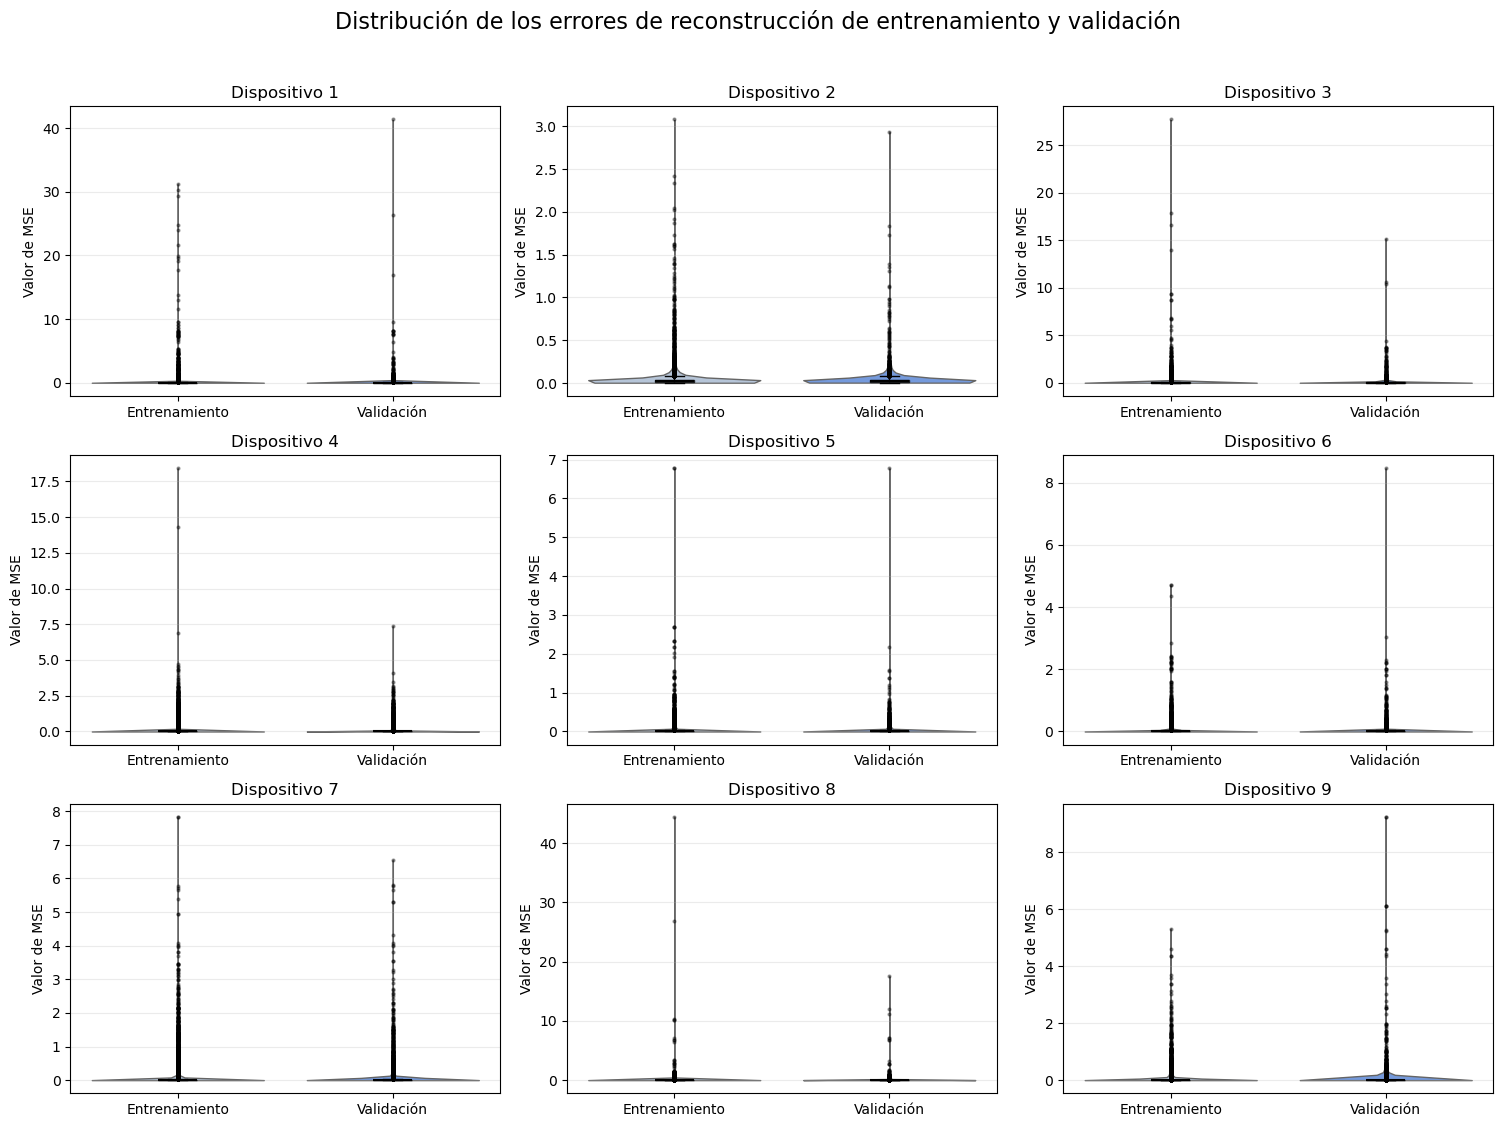

In [15]:
split_palette = {
    "Entrenamiento": "lightsteelblue",
    "Validación": "cornflowerblue",
}

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=False)
for ax, device_id in zip(axes.flatten(), range(1, 10)):
    device_errors_df = ae_errors_plot_df[
        ae_errors_plot_df["device"] == device_id
    ]

    sns.violinplot(
        data=device_errors_df,
        x="split",
        y="reconstruction_error",
        hue="split",
        palette=split_palette,
        inner=None,
        cut=0,
        linewidth=1,
        dodge=False,
        legend=False,
        ax=ax,
    )

    sns.boxplot(
        data=device_errors_df,
        x="split",
        y="reconstruction_error",
        width=0.18,
        showcaps=True,
        showfliers=True,
        boxprops={
            "facecolor": "white",
            "edgecolor": "black",
            "linewidth": 1,
            "alpha": 0.85,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1,
        },
        capprops={
            "color": "black",
            "linewidth": 1,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.5,
        },
        flierprops={
            "marker": "o",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 2,
            "alpha": 0.35,
        },
        ax=ax,
    )

    ax.set_title(f"Dispositivo {device_id}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Valor de MSE")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Distribución de los errores de reconstrucción de entrenamiento y validación",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()

In [16]:
ks_results = []
for device_id in sorted(ae_errors_plot_df["device"].unique()):
    train_scores = ae_train_errors_df.loc[
        ae_train_errors_df["device"] == device_id,
        "reconstruction_error",
    ].to_numpy()

    val_scores = ae_val_errors_df.loc[
        ae_val_errors_df["device"] == device_id,
        "reconstruction_error",
    ].to_numpy()

    ks_statistic, _ = ks_2samp(train_scores, val_scores)

    ks_results.append(
        {
            "device": device_id,
            "ks_statistic": ks_statistic,
            "train_mean": np.mean(train_scores),
            "val_mean": np.mean(val_scores),
            "train_median": np.median(train_scores),
            "val_median": np.median(val_scores),
            "train_std": np.std(train_scores),
            "val_std": np.std(val_scores),
            "train_max": np.max(train_scores),
            "val_max": np.max(val_scores),
        }
    )

ks_results_df = pd.DataFrame(ks_results)

ks_results_df

,device,ks_statistic,train_mean,val_mean,train_median,val_median,train_std,val_std,train_max,val_max
0,1,0.008108,0.059357,0.057659,0.007935,0.008153,0.565842,0.607491,31.250210,41.341427
1,2,0.014929,0.052618,0.049067,0.021651,0.021480,0.133469,0.125707,3.080207,2.938203
2,3,0.005968,0.051387,0.054737,0.009616,0.009646,0.343898,0.316782,27.692793,15.161528
3,4,0.004423,0.035793,0.034611,0.005558,0.005551,0.165840,0.147319,18.420197,7.377316
4,5,0.008512,0.022656,0.022115,0.007568,0.007526,0.087497,0.087838,6.779467,6.779467
5,6,0.011550,0.021035,0.022699,0.009876,0.010022,0.072513,0.096056,4.713332,8.469193
6,7,0.009524,0.045689,0.050161,0.004342,0.004410,0.224743,0.255719,7.833875,6.552156
7,8,0.011198,0.031169,0.033969,0.005301,0.005267,0.350465,0.303914,44.468826,17.570860
8,9,0.015986,0.047951,0.067813,0.001524,0.001525,0.212619,0.391011,5.320692,9.243902


Las distribuciones de los errores de reconstrucción obtenidas para los 9 dispositivos presentan un comportamiento muy consistente tanto entre dispositivos como entre los conjuntos de entrenamiento y validación. En todos los casos puede observarse que la mayor parte de las muestras benignas se concentran en valores de MSE muy próximos a 0, mientras que únicamente un reducido número de observaciones presenta errores de reconstrucción elevados. Como consecuencia, todas las distribuciones muestran una marcada asimetría positiva y una cola derecha, comportamiento esperable en un detector basado en autoencoders entrenado exclusivamente con tráfico benigno.

No obstante, a diferencia de lo observado durante el estudio de los *anomaly scores* de LOF, las colas de estas distribuciones son sensiblemente menos pronunciadas. Aunque siguen existiendo valores extremos, la diferencia entre los valores centrales (media y mediana) y los máximos observados resulta considerablemente menor que en LOF, lo que indica que el autoencoder genera distribuciones de errores más compactas y homogéneas sobre el tráfico benigno.

La comparación entre las distribuciones de entrenamiento y validación muestra además un elevado grado de similitud para todos los dispositivos. Esta observación se confirma cuantitativamente mediante el estadístico de Kolmogorov-Smirnov, cuyos valores oscilan entre **0.0044** y **0.0160**, evidenciando que ambas distribuciones apenas presentan diferencias. Asimismo, los estadísticos descriptivos muestran valores prácticamente idénticos para la media, la mediana y la desviación típica en ambos conjuntos, reforzando la idea de que los modelos mantienen un comportamiento muy estable sobre muestras benignas no utilizadas durante el entrenamiento.

Estos resultados indican que los autoencoders no han sobreajustado el conjunto de entrenamiento, sino que han aprendido una representación suficientemente general del comportamiento normal de cada dispositivo IoT. En consecuencia, la distribución de errores obtenida sobre el conjunto de validación constituye una base adecuada para estudiar distintos criterios de selección del *threshold* de detección de anomalías.

## 2. Selección del criterio de *threshold*

A partir de los resultados observados en el apartado anterior, las distribuciones presentan una fuerte concentración de valores próximos a cero, asimetría positiva y colas derechas, aunque menos extremas que las observadas en LOF. Por este motivo, el análisis se centrará en criterios basados en percentiles altos de la distribución, ya que permiten controlar de forma directa la proporción de muestras benignas de validación que quedarían por encima del threshold.

Adicionalmente, se incluye un criterio basado en media y desviación típica como referencia, aunque su interpretación debe realizarse con cautela debido a que las distribuciones no presentan un comportamiento gaussiano.

In [11]:
threshold_criteria = {
    "p99": lambda errors: np.percentile(errors, 99),
    "p99_5": lambda errors: np.percentile(errors, 99.5),
    "p99_9": lambda errors: np.percentile(errors, 99.9),
    "mean_3std": lambda errors: np.mean(errors) + 3 * np.std(errors),
}


results = []
for device in sorted(ae_val_errors_df["device"].unique()):

    errors = ae_val_errors_df.loc[
        ae_val_errors_df["device"] == device,
        "reconstruction_error"
    ].to_numpy()

    for criterion, func in threshold_criteria.items():

        threshold = func(errors)

        results.append({
            "device": device,
            "criterion": criterion,
            "threshold": threshold,
            "fpr (%)": 100 * np.mean(errors > threshold),
        })

ae_threshold_results_df = pd.DataFrame(results)

# Tabla de thresholds

print("Tabla de thresholds:")
display(
    ae_threshold_results_df.pivot(
        index="device",
        columns="criterion",
        values="threshold",
    ).round(6)
)

# Tabla de FPR estimada en validación

print("Tabla de FPR:")
display(
    ae_threshold_results_df.pivot(
        index="device",
        columns="criterion",
        values="fpr (%)",
    ).round(4)
)

Tabla de thresholds:


criterion,mean_3std,p99,p99_5,p99_9
device,,,,
1,1.880131,0.758834,1.401952,7.675197
2,0.426187,0.591450,0.850366,1.519775
3,1.005084,0.810168,1.681967,3.670982
4,0.476567,0.623424,0.929134,1.963607
5,0.285629,0.266756,0.409210,0.788354
6,0.310868,0.175659,0.370541,1.130443
7,0.817317,1.110478,1.553718,3.694119
8,0.945712,0.355215,0.637747,2.774950
9,1.240847,1.396012,2.153794,6.110636


Tabla de FPR:


criterion,mean_3std,p99,p99_5,p99_9
device,,,,
1,0.3835,1.0091,0.5045,0.0807
2,1.6012,1.0294,0.5337,0.1144
3,0.7801,0.9974,0.5115,0.1023
4,1.5151,1.0015,0.5022,0.1027
5,0.8768,1.0056,0.5068,0.1046
6,0.5837,1.0049,0.5025,0.1015
7,1.4861,1.0067,0.5081,0.1055
8,0.2791,1.0089,0.5045,0.1073
9,1.1265,1.0241,0.5120,0.0512


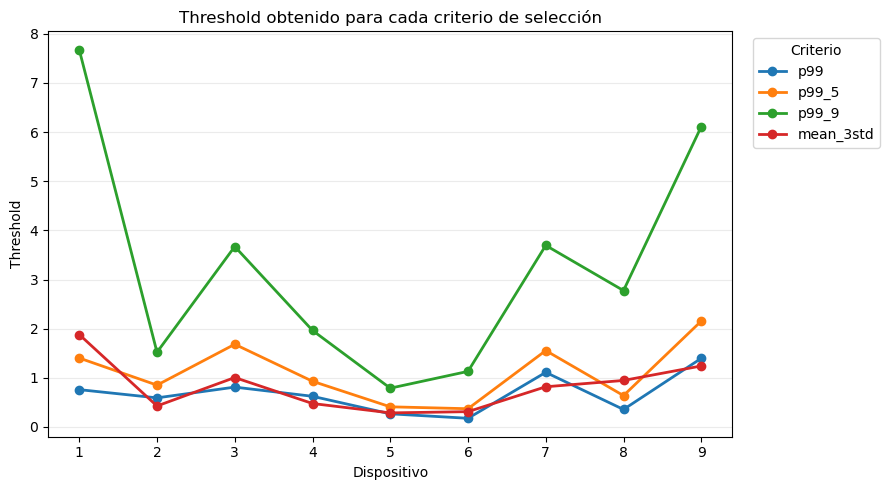

In [12]:
plt.figure(figsize=(9, 5))

for criterion in ae_threshold_results_df["criterion"].unique():

    criterion_df = ae_threshold_results_df[
        ae_threshold_results_df["criterion"] == criterion
    ]

    plt.plot(
        criterion_df["device"],
        criterion_df["threshold"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("Threshold obtenido para cada criterio de selección")
plt.xlabel("Dispositivo")
plt.ylabel("Threshold")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

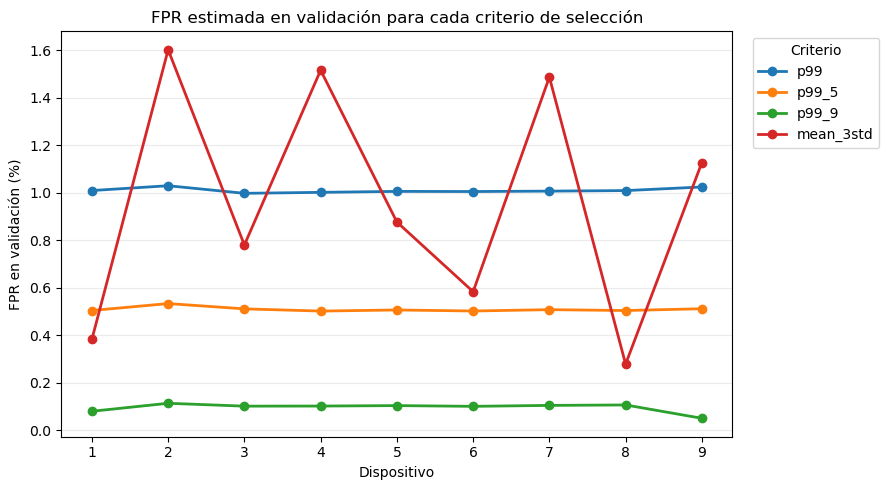

In [13]:
plt.figure(figsize=(9, 5))

for criterion in ae_threshold_results_df["criterion"].unique():

    criterion_df = ae_threshold_results_df[
        ae_threshold_results_df["criterion"] == criterion
    ]

    plt.plot(
        criterion_df["device"],
        criterion_df["fpr (%)"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("FPR estimada en validación para cada criterio de selección")
plt.xlabel("Dispositivo")
plt.ylabel("FPR en validación (%)")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Los resultados obtenidos muestran que los criterios basados en percentiles presentan un comportamiento completamente consistente con su definición estadística. En todos los dispositivos, los criterios **p99**, **p99.5** y **p99.9** generan tasas de falsos positivos próximas al **1 %**, **0.5 %** y **0.1 %**, respectivamente, lo que demuestra que permiten controlar de forma precisa la proporción de muestras benignas que quedarían clasificadas como anómalas.

Por el contrario, el criterio basado en **media + 3 desviaciones típicas** ofrece un comportamiento considerablemente menos uniforme. Aunque la FPR obtenida se mantiene en valores reducidos para todos los dispositivos, esta oscila aproximadamente entre **0.3 %** y **1.6 %**, mostrando una variabilidad significativamente superior a la observada en los criterios basados en percentiles. Este comportamiento era esperable, ya que la media y la desviación típica se ven afectadas por la forma de la distribución y por la presencia de valores extremos, mientras que los percentiles permiten controlar directamente la proporción de muestras benignas situadas por encima del *threshold* independientemente de la distribución concreta de cada dispositivo.

En cuanto a los valores absolutos de los *thresholds*, puede observarse una variabilidad considerable entre dispositivos para todos los criterios evaluados. Sin embargo, este comportamiento no supone una limitación de la metodología propuesta, sino una consecuencia natural del entrenamiento independiente de un autoencoder para cada dispositivo IoT. Cada modelo aprende una representación distinta del comportamiento normal de su dispositivo, por lo que la escala de los errores de reconstrucción carece de significado global y únicamente resulta interpretable dentro de la distribución de errores correspondiente a cada dispositivo.

A partir de estos resultados, los criterios basados en percentiles se consideran los candidatos más adecuados para la selección del *threshold*, ya que proporcionan un control directo y consistente sobre la tasa de falsos positivos esperada en validación. Entre ellos, el criterio **p99** representa la alternativa más equilibrada, al mantener una tasa de falsos positivos reducida sin incrementar el *threshold* de forma tan conservadora como ocurre en los criterios **p99.5** y **p99.9**, lo que previsiblemente contribuirá a preservar una mayor capacidad de detección de anomalías. No obstante, esta hipótesis deberá confirmarse mediante el estudio de estabilidad realizado en el apartado siguiente.

## 3. Estabilidad de los *thresholds* seleccionados

El objetivo de este apartado no es evaluar la capacidad de detección frente a ataques, ya que esta evaluación se reserva para el conjunto de test. En cambio, se pretende estudiar la robustez estadística de los criterios de threshold definidos únicamente a partir de tráfico benigno. Un criterio será considerado más estable si produce thresholds con menor variabilidad ante pequeñas perturbaciones de la muestra de validación.

Dado el análisis realizado en el apartado anterior, este estudio se centrará en los criterios basados en percentiles altos, ya que son los que ofrecen un control más directo y consistente de la tasa de falsos positivos esperada en validación.

In [20]:
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

bootstrap_criteria = {
    "P99": 99,
    "P99.5": 99.5,
    "P99.9": 99.9,
}

rng = np.random.default_rng(RANDOM_SEED)

bootstrap_results = []
for device in sorted(ae_val_errors_df["device"].unique()):
    errors = ae_val_errors_df.loc[
        ae_val_errors_df["device"] == device,
        "reconstruction_error"
    ].to_numpy()

    n_samples = len(errors)

    for criterion, percentile in bootstrap_criteria.items():
        thresholds = []

        for _ in range(N_BOOTSTRAP):
            bootstrap_sample = rng.choice(
                errors,
                size=n_samples,
                replace=True,
            )

            thresholds.append(
                np.percentile(bootstrap_sample, percentile)
            )

        thresholds = np.array(thresholds)

        bootstrap_results.append({
            "device": device,
            "criterion": criterion,
            "mean_threshold": thresholds.mean(),
            "std_threshold": thresholds.std(ddof=1),
            "cv_threshold": thresholds.std(ddof=1) / thresholds.mean(),
            "ci_2_5": np.percentile(thresholds, 2.5),
            "ci_97_5": np.percentile(thresholds, 97.5),
        })

bootstrap_results_df = pd.DataFrame(bootstrap_results)

In [21]:
bootstrap_cv_table = (
    bootstrap_results_df
    .pivot(
        index="device",
        columns="criterion",
        values="cv_threshold",
    )
    .round(6)
)

bootstrap_cv_table

criterion,P99,P99.5,P99.9
device,,,
1,0.127511,0.120916,0.229025
2,0.138699,0.110893,0.217498
3,0.117738,0.105122,0.142974
4,0.042821,0.045516,0.040907
5,0.060030,0.077057,0.152275
6,0.076836,0.102713,0.138097
7,0.068790,0.057387,0.143501
8,0.065567,0.161050,0.528297
9,0.138197,0.194192,0.180200


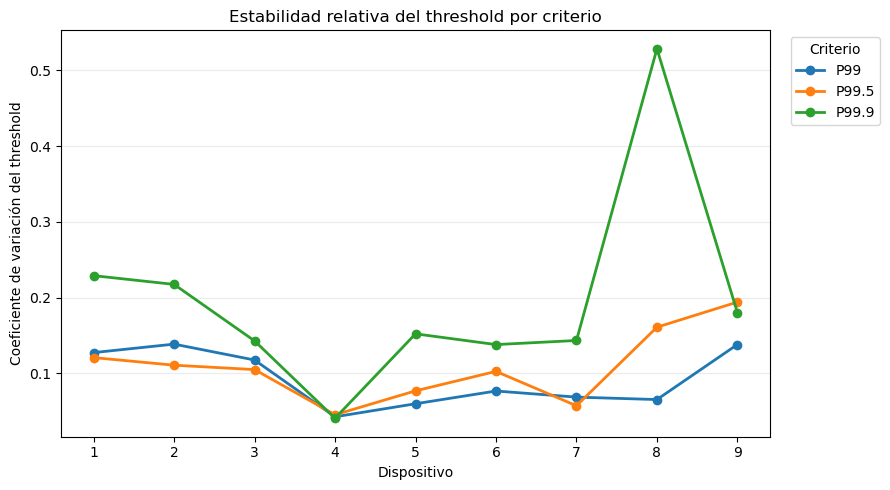

In [22]:
plt.figure(figsize=(9, 5))

for criterion in bootstrap_results_df["criterion"].unique():
    criterion_df = bootstrap_results_df[
        bootstrap_results_df["criterion"] == criterion
    ]

    plt.plot(
        criterion_df["device"],
        criterion_df["cv_threshold"],
        marker="o",
        linewidth=2,
        label=criterion,
    )

plt.title("Estabilidad relativa del threshold por criterio")
plt.xlabel("Dispositivo")
plt.ylabel("Coeficiente de variación del threshold")
plt.xticks(range(1, 10))
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Criterio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

El análisis de estabilidad confirma que los 3 criterios basados en percentiles presentan un comportamiento robusto frente a pequeñas perturbaciones del conjunto de validación. Sin embargo, existen diferencias significativas entre ellos en cuanto a la variabilidad relativa de los *thresholds* obtenidos.

El criterio **p99** presenta el comportamiento más uniforme entre dispositivos, manteniendo coeficientes de variación reducidos y sin mostrar incrementos bruscos en ninguno de los modelos entrenados. Por su parte, el criterio **p99.5** ofrece una estabilidad muy similar en la mayoría de los dispositivos, aunque comienza a mostrar una mayor sensibilidad en aquellos cuya distribución de errores presenta colas más pronunciadas. Esta diferencia resulta especialmente evidente en los dispositivos 8 y 9, donde la variabilidad del threshold aumenta de forma apreciable respecto a **p99**. Finalmente, el criterio **p99.9** es el que presenta el peor comportamiento, mostrando una mayor variabilidad en prácticamente todos los dispositivos y alcanzando valores especialmente elevados en el dispositivo 8. Este resultado era esperable, ya que cuanto más extremo es el percentil seleccionado, mayor es la influencia que ejercen los valores más alejados de la distribución sobre el cálculo del threshold.

Estos resultados complementan el análisis realizado en el apartado anterior. Mientras que los criterios basados en percentiles permitían controlar de forma precisa la tasa de falsos positivos esperada sobre el conjunto de validación, el estudio de estabilidad pone de manifiesto que aumentar excesivamente el percentil también incrementa la sensibilidad del threshold frente a pequeñas variaciones de la muestra utilizada para estimarlo. En consecuencia, aunque **p99.5** y **p99.9** reducen progresivamente la tasa de falsos positivos estimada, dicha reducción se consigue a costa de obtener *thresholds* más conservadores y menos estables.

A la vista de ambos análisis, el criterio **p99** se considera la alternativa más equilibrada para el cálculo del threshold de detección de anomalías. Este criterio mantiene una tasa de falsos positivos reducida y perfectamente controlada, proporciona los *thresholds* más estables entre dispositivos y evita incrementar el umbral de decisión más de lo necesario, reduciendo así el riesgo de disminuir la sensibilidad del detector frente a anomalías. Por todo ello, **el percentil 99 de la distribución de errores de reconstrucción sobre el conjunto de validación se selecciona como criterio de cálculo del threshold para la evaluación de los autoencoders entrenados por dispositivo IoT durante el resto de la experimentación.**

# Estudio de *threshold* de Autoencoder global

## 1. Caracterización de los errores de reconstrucción

En este apartado se analiza la distribución de los errores de reconstrucción obtenidos por el autoencoder global sobre los conjuntos de entrenamiento y validación, ambos compuestos exclusivamente por tráfico benigno. El objetivo es comprobar si el modelo mantiene un comportamiento consistente sobre datos no utilizados durante el entrenamiento y verificar que la distribución de errores del conjunto de validación resulta adecuada para estudiar posteriormente distintos criterios de selección del *threshold* de detección de anomalías.

Para ello, se comparan visualmente ambas distribuciones mediante un diagrama de violín y se calculan diversos estadísticos descriptivos, incluyendo la media, la mediana, la desviación típica y el valor máximo observado. Además, se emplea el estadístico de Kolmogorov-Smirnov como medida cuantitativa de similitud entre ambas distribuciones.

In [18]:
# Juntar los dataframes de errores de reconstrucción de entrenamiento y validación para poder graficarlos juntos
aeg_train_plot_df = aeg_train_errors_df.copy()
aeg_train_plot_df["split"] = "Entrenamiento"

aeg_val_plot_df = aeg_val_errors_df.copy()
aeg_val_plot_df["split"] = "Validación"

aeg_errors_plot_df = pd.concat(
    [aeg_train_plot_df, aeg_val_plot_df],
    ignore_index=True,
)

aeg_errors_plot_df["split"] = pd.Categorical(
    aeg_errors_plot_df["split"],
    categories=["Entrenamiento", "Validación"],
    ordered=True,
)

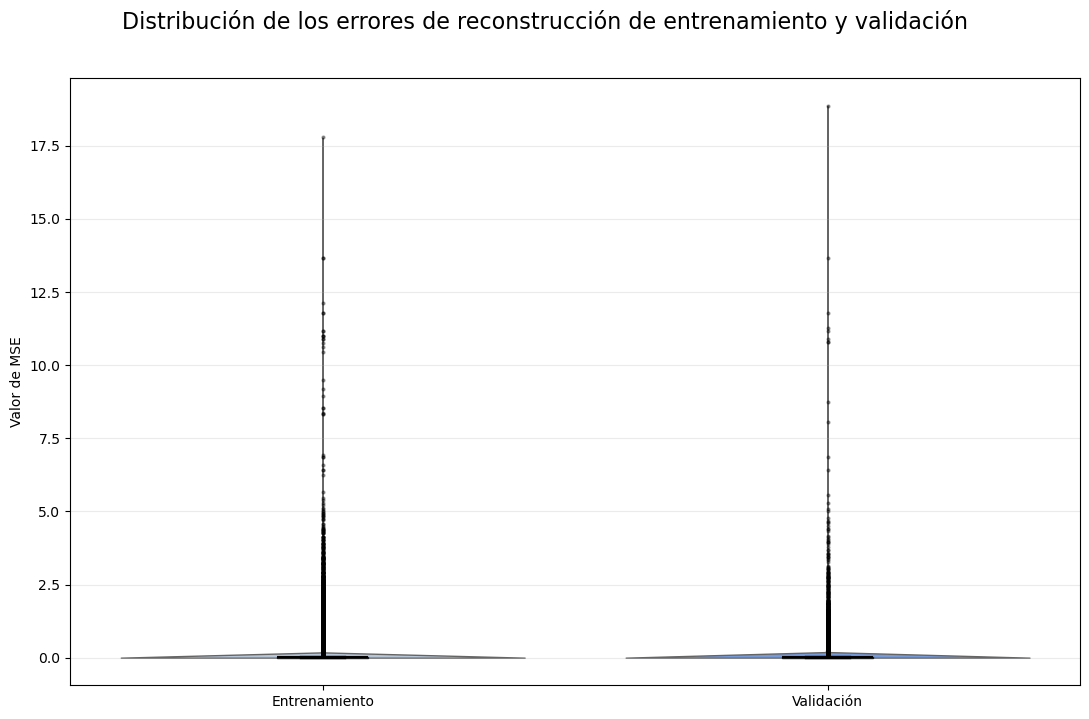

In [19]:
split_palette = {
    "Entrenamiento": "lightsteelblue",
    "Validación": "cornflowerblue",
}

fig, axes = plt.subplots(figsize=(11, 7), sharey=False)
sns.violinplot(
    data=aeg_errors_plot_df,
    x="split",
    y="reconstruction_error",
    hue="split",
    palette=split_palette,
    inner=None,
    cut=0,
    linewidth=1,
    dodge=False,
    legend=False,
    ax=axes,
)

sns.boxplot(
    data=aeg_errors_plot_df,
    x="split",
    y="reconstruction_error",
    width=0.18,
    showcaps=True,
    showfliers=True,
    boxprops={
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1,
        "alpha": 0.85,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1,
    },
    capprops={
        "color": "black",
        "linewidth": 1,
    },
    medianprops={
        "color": "black",
        "linewidth": 1.5,
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 2,
        "alpha": 0.35,
    },
    ax=axes,
)


axes.set_xlabel("")
axes.set_ylabel("Valor de MSE")
axes.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Distribución de los errores de reconstrucción de entrenamiento y validación",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()

In [20]:
train_scores = aeg_train_errors_df["reconstruction_error"].to_numpy()

val_scores = aeg_val_errors_df["reconstruction_error"].to_numpy()

ks_statistic, _ = ks_2samp(train_scores, val_scores)

ks_results = {
        "ks_statistic": ks_statistic,
        "train_mean": np.mean(train_scores),
        "val_mean": np.mean(val_scores),
        "train_median": np.median(train_scores),
        "val_median": np.median(val_scores),
        "train_std": np.std(train_scores),
        "val_std": np.std(val_scores),
        "train_max": np.max(train_scores),
        "val_max": np.max(val_scores),
}

ks_results_df = pd.DataFrame([ks_results])

display(ks_results_df)

,ks_statistic,train_mean,val_mean,train_median,val_median,train_std,val_std,train_max,val_max
0,0.002689,0.037537,0.037142,0.006468,0.006437,0.181779,0.188733,17.786768,18.874891


Los resultados muestran que las distribuciones de errores de reconstrucción obtenidas sobre los conjuntos de entrenamiento y validación presentan un comportamiento prácticamente idéntico. Visualmente, ambos diagramas de violín muestran una elevada concentración de muestras con errores muy próximos a cero, una marcada asimetría positiva y la presencia de un reducido número de valores extremos de elevada magnitud. Asimismo, la dispersión observada en ambos conjuntos resulta prácticamente indistinguible.

Esta similitud se confirma mediante el estadístico de Kolmogorov-Smirnov, cuyo valor (**0.0027**) indica que las diferencias entre ambas distribuciones son prácticamente despreciables. Del mismo modo, los estadísticos descriptivos muestran valores muy similares para la media (0.0375 frente a 0.0371), la mediana (0.0065 frente a 0.0064) y la desviación típica (0.1818 frente a 0.1887). Incluso los valores máximos alcanzados en ambos conjuntos son muy próximos, reflejando la presencia de observaciones benignas difíciles de reconstruir tanto durante el entrenamiento como en la validación.

En conjunto, estos resultados indican que el autoencoder global no presenta evidencias de sobreajuste y ha aprendido una representación estable del comportamiento benigno agregado de los distintos dispositivos IoT incluidos en el entrenamiento. En consecuencia, la distribución de errores obtenida sobre el conjunto de validación constituye una base adecuada para estudiar distintos criterios de selección del *threshold* de detección de anomalías.

## 2. Selección del criterio de *threshold*

A partir de los resultados obtenidos en el apartado anterior, se observa que la distribución de errores de reconstrucción presenta una elevada concentración de valores próximos a cero, una marcada asimetría positiva y una cola derecha formada por un número reducido de observaciones extremas. Dado que este comportamiento no se ajusta a una distribución simétrica ni gaussiana, la selección del *threshold* se centrará principalmente en criterios basados en percentiles altos, ya que permiten controlar directamente la proporción de muestras benignas de validación que quedarían por encima del umbral.

En concreto, se evaluarán los percentiles **99**, **99.5** y **99.9** de la distribución de errores de reconstrucción. Además, se incluirá como referencia el criterio **μ + 3σ**, utilizado también en la experimentación del autoencoder por dispositivo, con el objetivo de comprobar si una regla basada en media y dispersión resulta competitiva frente a los criterios percentílicos.

Para cada criterio se calculará el valor del *threshold* correspondiente y la tasa de falsos positivos (FPR) asociada sobre el conjunto de validación. La decisión final se basará en el equilibrio entre mantener una tasa de falsos positivos controlada y evitar un incremento excesivo del umbral, que podría reducir la sensibilidad del detector ante muestras anómalas.

In [27]:
# Criterios de threshold a evaluar
aeg_threshold_criteria = {
    "media + 3std": aeg_val_errors_df["reconstruction_error"].mean()
    + 3 * aeg_val_errors_df["reconstruction_error"].std(),
    "p99": aeg_val_errors_df["reconstruction_error"].quantile(0.99),
    "p99.5": aeg_val_errors_df["reconstruction_error"].quantile(0.995),
    "p99.9": aeg_val_errors_df["reconstruction_error"].quantile(0.999),
}

# Cálculo del threshold y FPR asociado para cada criterio
aeg_threshold_results = []

for criterion, threshold in aeg_threshold_criteria.items():
    fpr = (aeg_val_errors_df["reconstruction_error"] > threshold).mean()

    aeg_threshold_results.append(
        {
            "criterion": criterion,
            "threshold": threshold,
            "fpr": fpr,
            "fpr_percent": round(fpr * 100, 2),
        }
    )

aeg_threshold_results_df = pd.DataFrame(aeg_threshold_results)

aeg_threshold_results_df

,criterion,threshold,fpr,fpr_percent
0,media + 3std,0.603343,0.008931,0.89
1,p99,0.556167,0.010001,1.00
2,p99.5,0.920816,0.005001,0.50
3,p99.9,2.244136,0.001007,0.10


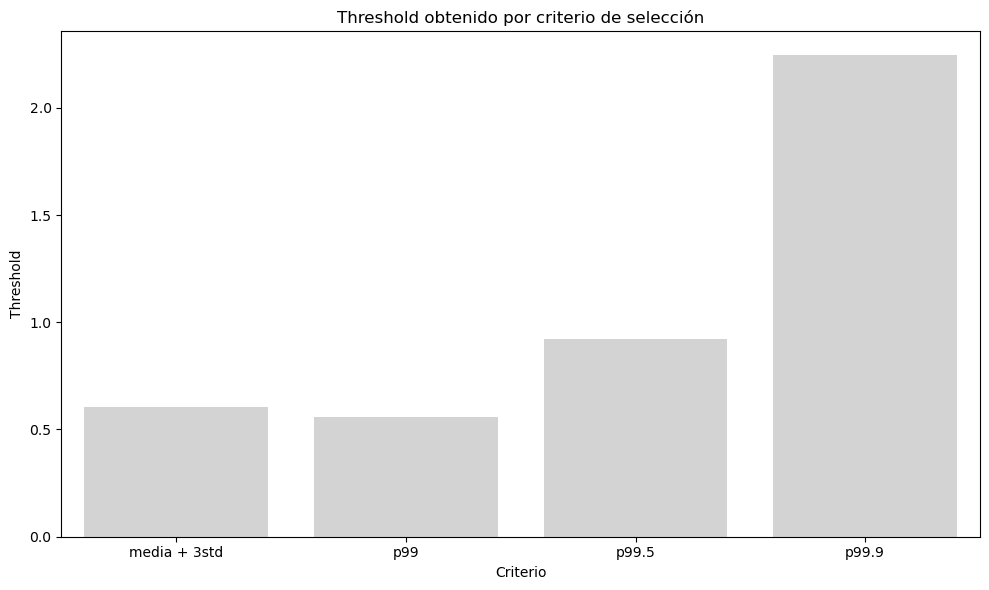

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=aeg_threshold_results_df,
    x="criterion",
    y="threshold",
    ax=ax,
    color="lightgrey"
)

ax.set_title("Threshold obtenido por criterio de selección")
ax.set_xlabel("Criterio")
ax.set_ylabel("Threshold")

plt.tight_layout()
plt.show()

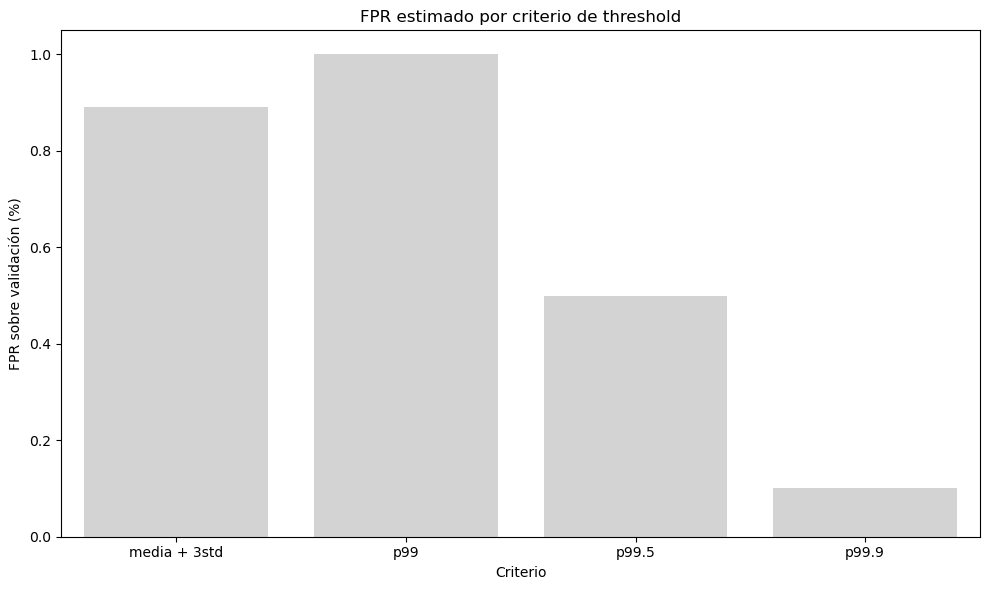

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=aeg_threshold_results_df,
    x="criterion",
    y="fpr_percent",
    ax=ax,
    color="lightgrey"
)

ax.set_title("FPR estimado por criterio de threshold")
ax.set_xlabel("Criterio")
ax.set_ylabel("FPR sobre validación (%)")

plt.tight_layout()
plt.show()

Los resultados obtenidos muestran que los criterios basados en percentiles altos producen el comportamiento esperado: a medida que el *threshold* aumenta, la tasa de falsos positivos (FPR) disminuye progresivamente. Sin embargo, esta reducción no es uniforme respecto al incremento del umbral. En particular, el criterio **p99.9** requiere multiplicar considerablemente el valor del *threshold* respecto a **p99.5**, mientras que la reducción adicional del FPR resulta relativamente modesta. Este comportamiento indica que incrementar excesivamente el umbral podría reducir la sensibilidad del detector frente a anomalías sin aportar una mejora proporcional en el control de falsas alarmas.

Por otro lado, el criterio **μ + 3σ** presenta un comportamiento muy próximo al percentil **99**, obteniendo un *threshold* ligeramente superior y una reducción marginal de la tasa de falsos positivos. No obstante, esta mejora resulta poco significativa y se consigue incrementando el umbral de decisión.

Considerando el equilibrio entre mantener un *threshold* contenido y una tasa de falsos positivos reducida, así como la coherencia con el criterio empleado durante la optimización del modelo, se selecciona **el percentil 99** como criterio para el cálculo del *threshold* de detección de anomalías en el autoencoder global. Este criterio proporciona un compromiso adecuado entre robustez y sensibilidad, evitando incrementos innecesarios del umbral que puedan dificultar la detección de muestras anómalas.

En consecuencia, el *threshold* seleccionado para el resto de la experimentación es **0.5562**.